# Evaluación y Optimización de Modelos de Clasificación
**Dataset:** Breast Cancer (sklearn)  

En esta práctica se va a utilizar el dataset Breast Cancer Wisconsin de sklearn para entrenar un modelo de Regresión Logística y se evaluará su desempeño mediante diferentes métricas de clasificación, validación cruzada, optimización de hiperparámetros y ajuste del umbral de decisión.

In [130]:
# Importación de las librerias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import (
    train_test_split, cross_val_score,
    GridSearchCV, RandomizedSearchCV, KFold)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, classification_report)

print("\nLibrerias importadas correctamente\n")




Librerias importadas correctamente



# 1. Carga y exploración del dataset

In [131]:
data = load_breast_cancer()
X = data.data
y = data.target

print("Datasets cargado correctamente\n")
df = pd.DataFrame(X, columns = data.feature_names)
df["Diagnosis"] = y
df.head()



Datasets cargado correctamente



,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [132]:
print("Información básica sobre el datasets")
print("\nNúmero de muestras: ", X.shape[0])
print("Número de variables: ", X.shape[1])
print("\n", df["Diagnosis"].value_counts())



Información básica sobre el datasets

Número de muestras:  569
Número de variables:  30

 Diagnosis
1    357
0    212
Name: count, dtype: int64


División de los datos para el entrenamiemto 80% y para la prueba 20%

In [133]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42, stratify = y
)

# Escalado de las variables
scaler = StandardScaler()

X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print("DIVISIÓN Y PREPROCESAMIENTO")
print(f"\nTamaño del conjunto de entrenamiento: {X_train.shape[0]} muestras")
print(f"Tamaño del conjunto de prueba: {X_test.shape[0]} muestras\n")



DIVISIÓN Y PREPROCESAMIENTO

Tamaño del conjunto de entrenamiento: 455 muestras
Tamaño del conjunto de prueba: 114 muestras



# 2. Entrenamiento del modelo de regresión logistica

In [134]:
modelo = LogisticRegression(max_iter = 10000, random_state = 25)
modelo.fit(X_train_sc, y_train)

# Predicciones del modelo
y_pred = modelo.predict(X_test_sc)
y_prob = modelo.predict_proba(X_test_sc)[:,1]


# 3. Matriz de confusión


Grafica de la matriz de Confusión



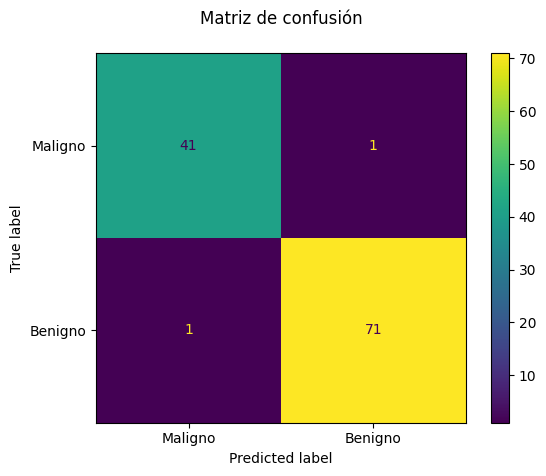

In [135]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay (
    confusion_matrix = cm,
    display_labels = ["Maligno", "Benigno"])

print(f"\nGrafica de la matriz de Confusión\n")
disp.plot()
plt.title("Matriz de confusión\n")
plt.show()




La matriz muestra que el modelo clasificó correctamente la mayoría de los tumores benignos y malignos, cometiendo pocos falsos positivos y falsos negativos

# 4. Cálculo de métricas


In [136]:
# Métrica de precisión
precision = precision_score(y_test, y_pred)

# Métrica de recall
recall = recall_score(y_test, y_pred)

# Métrica de f1_score
f1 = f1_score(y_test, y_pred)

# Métrica de auc_roc
auc = roc_auc_score(y_test, y_pred)

print("MÉTRICAS: PRECISIÓN, RECALL, F1-SCORE, AUC-ROC")
print("\nPrecisión:", precision)
print("Recall:", recall)
print("F1:", f1)
print("Auc-Roc:", auc)



MÉTRICAS: PRECISIÓN, RECALL, F1-SCORE, AUC-ROC

Precisión: 0.9861111111111112
Recall: 0.9861111111111112
F1: 0.9861111111111112
Auc-Roc: 0.9811507936507937


In [137]:
# resumen de las metricas
print(classification_report(y_test, y_pred))



              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114




Grafica de la Curva de ROC:



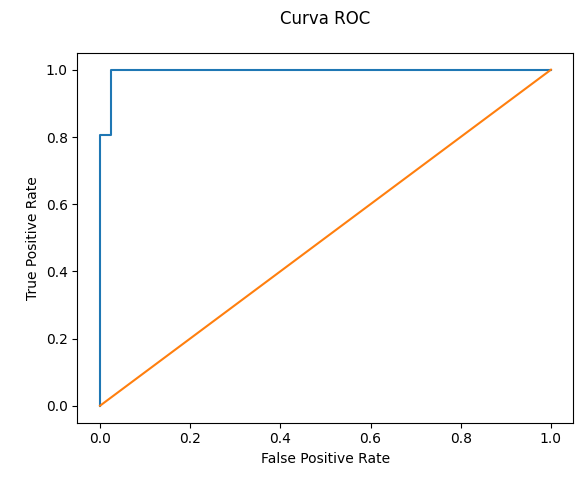

In [138]:
# Curva de ROC nos permite ver la diferencia entre ambas clases bajo los distintos umbrales
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)

plt.plot([0,1],[0,1])

plt.xlabel("False Positive Rate\n")

plt.ylabel("\nTrue Positive Rate")

plt.title("Curva ROC\n")

print("\nGrafica de la Curva de ROC:\n")

plt.show()



# 5. K-Fold Cross Validation con k=5 y k=10


K-FOLD CROSS-VALIDATION

K-Fold = 5
Scores: [0.9737 0.9801 0.9851 0.9863 0.9927]
Promedio: 0.9835786775026267 | Desv.Std: 0.006366156094255771

K-Fold = 10
Scores: [0.9867 0.9737 1.     0.9589 0.9831 0.9867 0.9877 0.9846 1.     0.9836]
Promedio: 0.9844848763886406 | Desv.Std: 0.011291053302662937


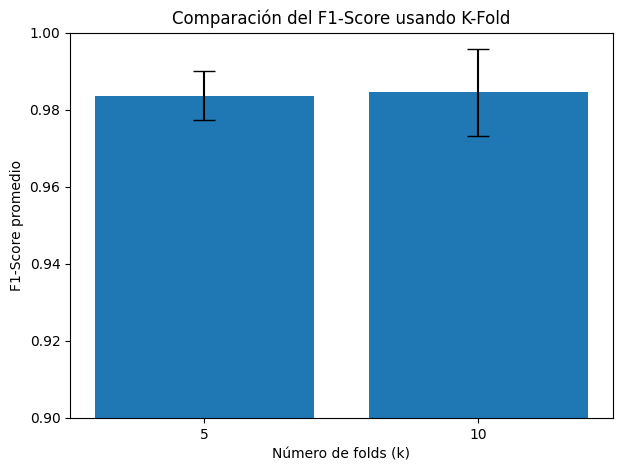

In [139]:
promedios, desviaciones, k_values = [], [], [5, 10]

print("K-FOLD CROSS-VALIDATION")

for k in k_values:
    kf = KFold(n_splits=k, shuffle=True, random_state=25)

    scores = cross_val_score(
        modelo,
        scaler.fit_transform(X),
        y,
        cv=kf,
        scoring="f1"
    )

    print(f"\nK-Fold = {k}")
    print("Scores:", np.round(scores, 4))
    print("Promedio:", scores.mean(), "| Desv.Std:", scores.std())

    promedios.append(scores.mean())
    desviaciones.append(scores.std())


# Gráfica
plt.figure(figsize=(7,5))

plt.bar(
    [str(k) for k in k_values],
    promedios,
    yerr=desviaciones,
    capsize=8
)

plt.xlabel("Número de folds (k)")
plt.ylabel("F1-Score promedio")
plt.title("Comparación del F1-Score usando K-Fold")

plt.ylim(0.9, 1.0)   # opcional

plt.show()



# 6. Hiperparámetros con GridSearchCV y RandomizedSearchCV

In [140]:
# Hiperparámetros con GridSearchCV
param_grid = {
    "C":[0.01,0.1,1,10],
    "solver":["liblinear", "lbfgs"]
}

grid = GridSearchCV(
    LogisticRegression(max_iter=5000, random_state = 25),
    param_grid,
    cv=5,
    scoring = "f1"
)

grid.fit(X_train_sc,y_train)
print("\nGRID SEARCH")
print("Mejores parámetros:", grid.best_params_)
print("Mejor F1 (CV):", grid.best_score_)



GRID SEARCH
Mejores parámetros: {'C': 0.1, 'solver': 'lbfgs'}
Mejor F1 (CV): 0.984524686809138


In [141]:
# Hiperparámetros con RandomizedSearchCV
param_dist = {
    "C":[0.01,0.1,1,10,100],
    "solver":["liblinear"]
}

random = RandomizedSearchCV(
    LogisticRegression(max_iter=1000),
    param_dist,
    n_iter=5,
    cv=5,
    random_state=42
)

random.fit(X_train_sc,y_train)
print("\nRANDOMIZED SEARCH")
print("Mejores parámetros:", random.best_params_)
print("Mejor F1 (CV):", random.best_score_)




RANDOMIZED SEARCH
Mejores parámetros: {'solver': 'liblinear', 'C': 1}
Mejor F1 (CV): 0.9802197802197803


# 7. Umbral de decisión

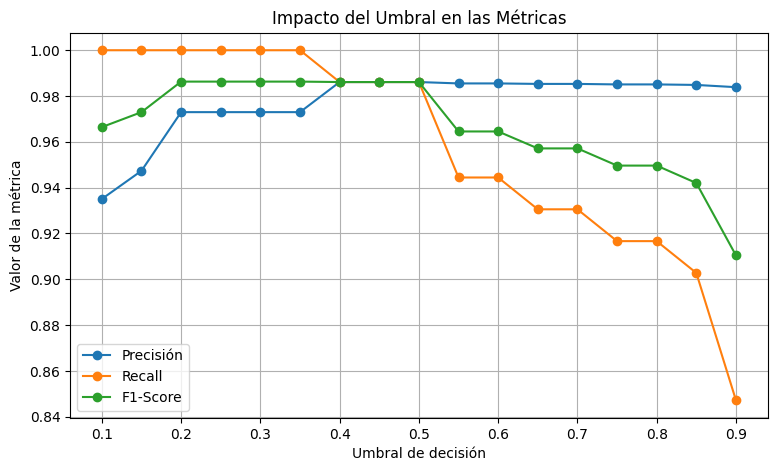

In [142]:
umbrales = np.arange(0.1,0.95,0.05)
precisions, recalls, f1_scores = [], [], []

for thresh in umbrales:
     # Nuevas predicciones según el umbral
    y_pred_nueva = (y_prob >= thresh).astype(int)

    # Métricas
    p = precision_score(y_test, y_pred_nueva, zero_division=0)
    r = recall_score(y_test, y_pred_nueva, zero_division=0)
    f = f1_score(y_test, y_pred_nueva, zero_division=0)

    # Guardar resultados
    precisions.append(p)
    recalls.append(r)
    f1_scores.append(f)


# Gráfico
plt.figure(figsize=(9,5))

plt.plot(umbrales, precisions, marker='o', label="Precisión")
plt.plot(umbrales, recalls, marker='o', label="Recall")
plt.plot(umbrales, f1_scores, marker='o', label="F1-Score")

plt.xlabel("Umbral de decisión")
plt.ylabel("Valor de la métrica")
plt.title("Impacto del Umbral en las Métricas")

plt.legend()
plt.grid(True)

plt.show()

print("")


Al disminuir el umbral aumenta el Recall porque el modelo detecta más casos positivos, aunque disminuye la Precisión debido al incremento de falsos positivos.